In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("outputs", exist_ok=True)

X = pd.read_parquet("data/X_scaled.parquet")
y = pd.read_parquet("data/y_binary.parquet")["BinaryLabel"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (9546, 65)
y distribution:
 BinaryLabel
0    5976
1    3570
Name: count, dtype: int64


In [2]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=20)
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
top20 = scores.head(20)
print("Top 20 features:\n", top20)

Top 20 features:
 Packet Length Min         92377.072638
Fwd Packet Length Min     87227.025325
Avg Packet Size           73124.781633
Avg Fwd Segment Size      70404.313570
Fwd Packet Length Mean    70404.313570
Packet Length Mean        62283.053603
Fwd Packet Length Max     17954.930683
Protocol                  10396.364607
Flow Bytes/s              10107.775137
Packet Length Max          5484.185167
URG Flag Count             4812.335636
Fwd Packets/s              4635.556467
Flow Packets/s             4517.009906
Down/Up Ratio              2984.478735
Init Fwd Win Bytes         1016.196553
CWE Flag Count              872.907644
ACK Flag Count              717.723801
Bwd IAT Min                 696.211206
Bwd Packet Length Min       688.193467
Packet Length Std           652.540686
dtype: float64


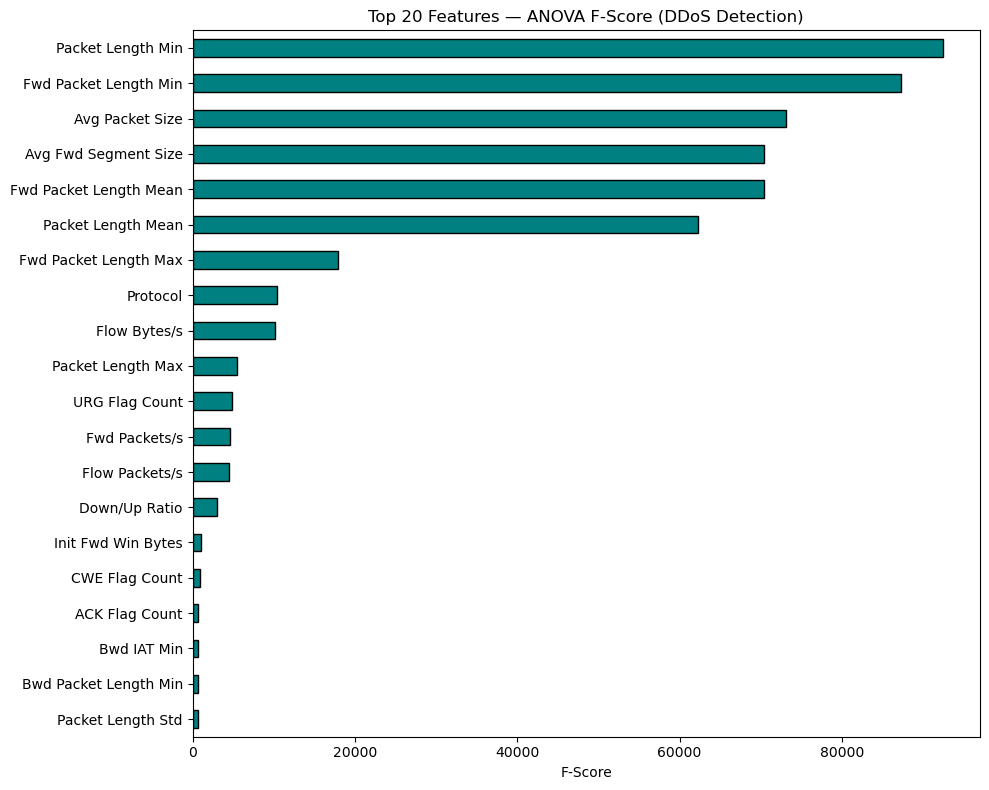

Saved: 04_top20_features.png


In [3]:
top20.sort_values().plot(kind="barh", figsize=(10,8), color="teal", edgecolor="black")
plt.title("Top 20 Features — ANOVA F-Score (DDoS Detection)")
plt.xlabel("F-Score")
plt.tight_layout()
plt.savefig("outputs/04_top20_features.png", dpi=150)
plt.show()
print("Saved: 04_top20_features.png")

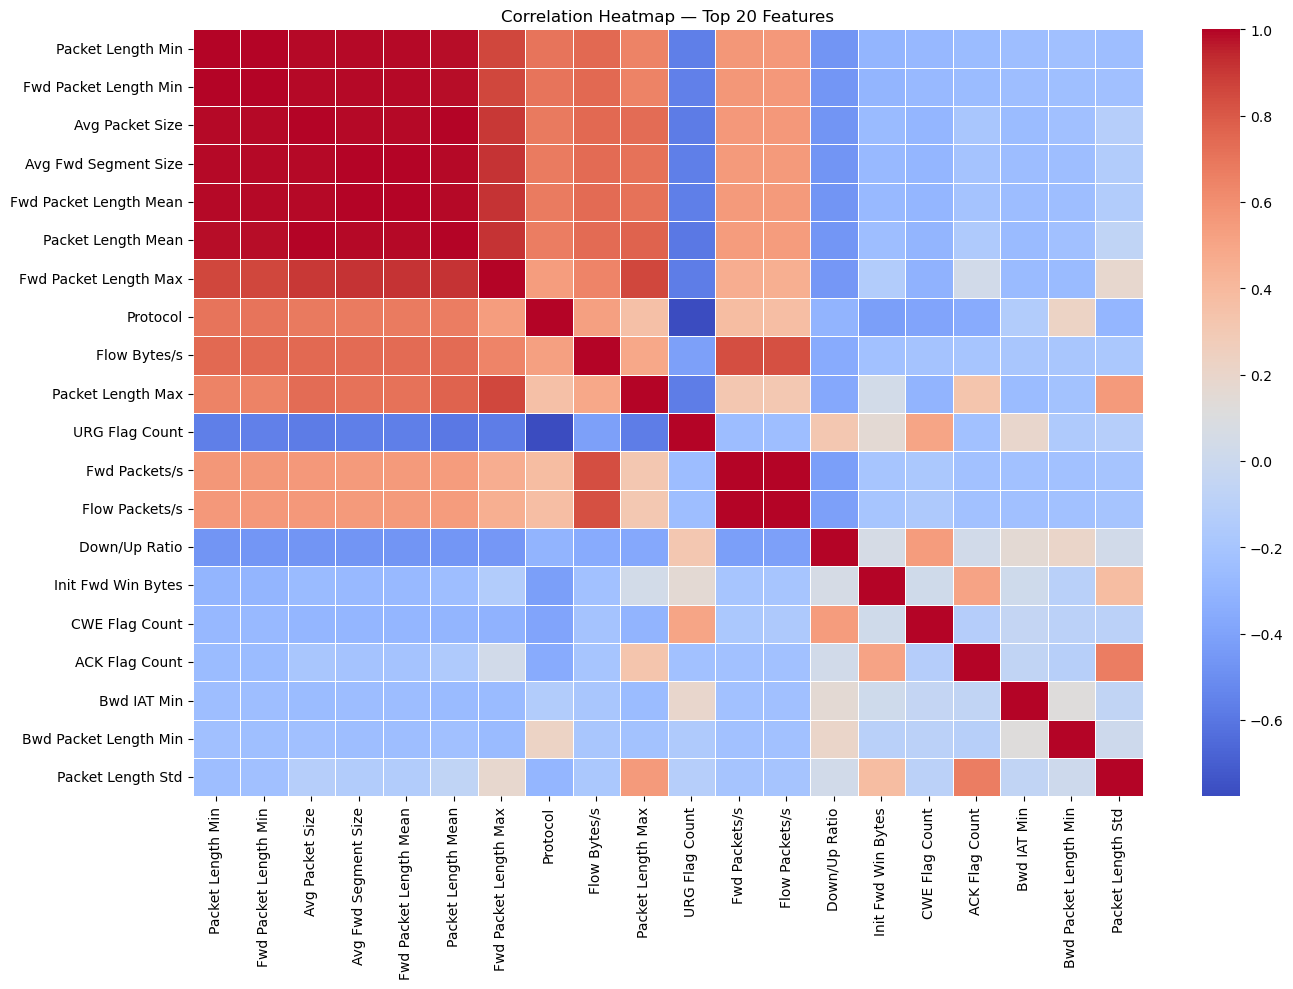

Saved: 05_correlation_heatmap.png


In [8]:
# Heatmap top 20
top20_cols = top20.index.tolist()
plt.figure(figsize=(14,10))
sns.heatmap(X[top20_cols].corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap — Top 20 Features")
plt.tight_layout()
plt.savefig("outputs/05_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: 05_correlation_heatmap.png")

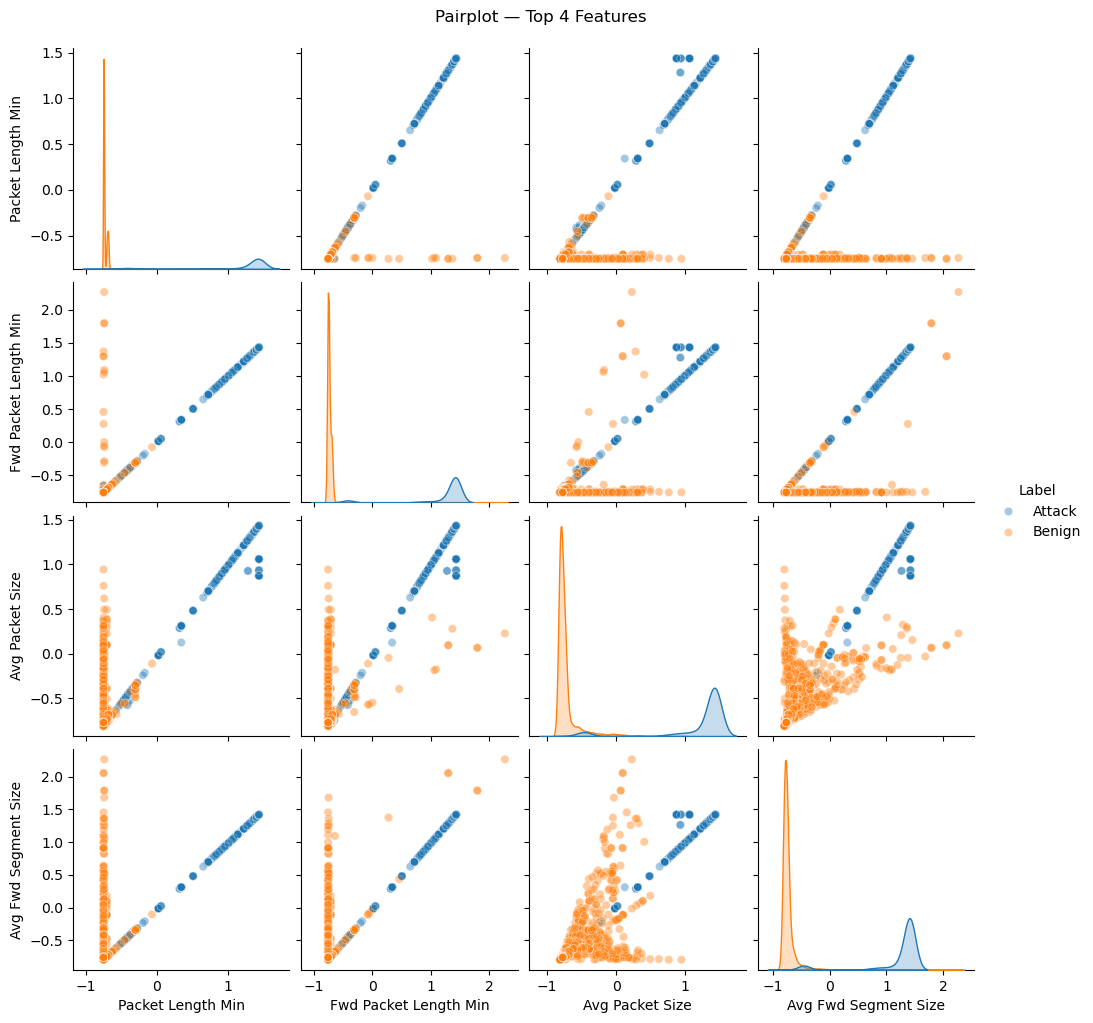

Saved: 06_pairplot.png


In [13]:
# Pairplot - of top 4 features:
plot_df = X[top20.head(4).index.tolist()].copy()
plot_df["Label"] = y.map({0:"Benign", 1:"Attack"})

sns.pairplot(plot_df, hue="Label", plot_kws={"alpha":0.4}, height=2.5)
plt.suptitle("Pairplot — Top 4 Features", y=1.02)
plt.savefig("outputs/07_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 06_pairplot.png")

In [12]:
import joblib

X_top20 = X[top20_cols]
X_top20.to_parquet("data/X_top20.parquet")
joblib.dump(top20_cols, "models/top20_features.pkl")

print("Saved: data/X_top20.parquet")
print("Features:", top20_cols)

Saved: data/X_top20.parquet
Features: ['Packet Length Min', 'Fwd Packet Length Min', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Packet Length Mean', 'Fwd Packet Length Max', 'Protocol', 'Flow Bytes/s', 'Packet Length Max', 'URG Flag Count', 'Fwd Packets/s', 'Flow Packets/s', 'Down/Up Ratio', 'Init Fwd Win Bytes', 'CWE Flag Count', 'ACK Flag Count', 'Bwd IAT Min', 'Bwd Packet Length Min', 'Packet Length Std']
